In [1]:
import pandas as pd
import numpy as np
import os
import joblib

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)

print("Model evaluation environment ready!")

Model evaluation environment ready!


In [2]:
data_path = "../data/CICIDS2017/ml_ready/cicids2017_binary_ml_ready.csv"

df = pd.read_csv(data_path)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
print("\nColumns:", len(df.columns))

Dataset loaded successfully!
Dataset shape: (288277, 79)

Columns: 79


In [3]:
columns_to_drop = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp",
    "Label",
    "Binary_Label"
]

X = df.drop(columns=columns_to_drop, errors="ignore")
y = df["Binary_Label"]

X = X.replace([np.inf, -np.inf], np.nan)

valid_rows = X.notna().all(axis=1)

X = X.loc[valid_rows].copy()
y = y.loc[valid_rows].copy()

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

Feature matrix shape: (288277, 78)
Target shape: (288277,)

Target distribution:
Binary_Label
0    200000
1     88277
Name: count, dtype: int64


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (230621, 78)
Testing data: (57656, 78)


In [5]:
model_path = "../models/random_forest_baseline.joblib"

rf_model = joblib.load(model_path)

print("Random Forest model loaded successfully!")

Random Forest model loaded successfully!


In [6]:
y_pred = rf_model.predict(X_test)

y_probability = rf_model.predict_proba(X_test)[:, 1]

print("Predictions generated successfully!")
print("Number of predictions:", len(y_pred))

Predictions generated successfully!
Number of predictions: 57656


In [7]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_probability)

print("Model Evaluation Results")
print("-" * 40)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Model Evaluation Results
----------------------------------------
Accuracy : 0.9978
Precision: 0.9968
Recall   : 0.9960
F1 Score : 0.9964
ROC-AUC  : 0.9997


In [8]:
print("Classification Report")
print("=" * 60)

print(
    classification_report(
        y_test,
        y_pred,
        target_names=["BENIGN", "ATTACK"],
        zero_division=0
    )
)

Classification Report
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00     40000
      ATTACK       1.00      1.00      1.00     17656

    accuracy                           1.00     57656
   macro avg       1.00      1.00      1.00     57656
weighted avg       1.00      1.00      1.00     57656



In [9]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[39944    56]
 [   71 17585]]


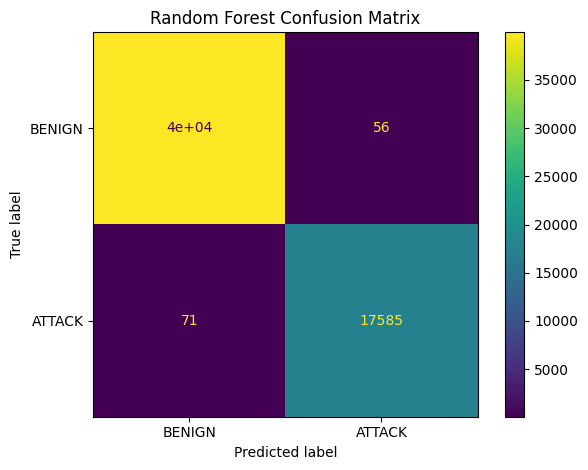

In [10]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "ATTACK"]
)

disp.plot()

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

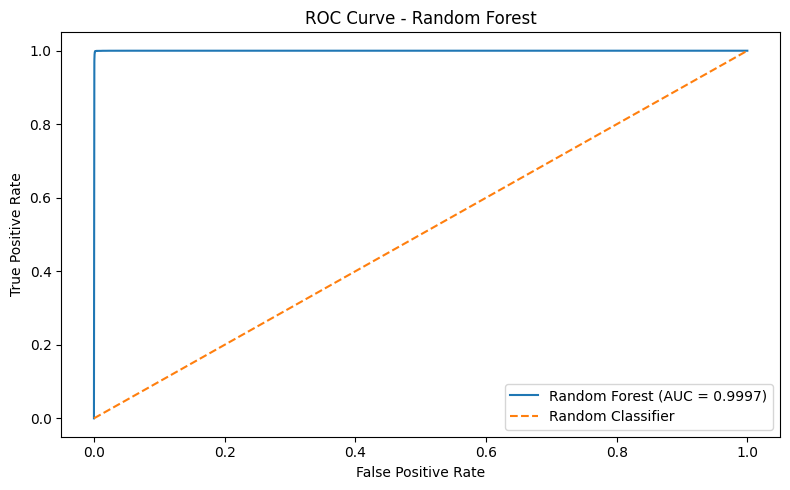

In [11]:
fpr, tpr, thresholds = roc_curve(
    y_test,
    y_probability
)

plt.figure(figsize=(8, 5))

plt.plot(
    fpr,
    tpr,
    label=f"Random Forest (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [12]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Top 20 Important Features:")
print(feature_importance.head(20))

Top 20 Important Features:
                        Feature  Importance
0              Destination Port    0.060657
39            Max Packet Length    0.054986
66       Init_Win_bytes_forward    0.045853
38            Min Packet Length    0.045756
11        Bwd Packet Length Min    0.042984
42       Packet Length Variance    0.037469
13        Bwd Packet Length Std    0.036536
54         Avg Bwd Segment Size    0.033323
41            Packet Length Std    0.032143
10        Bwd Packet Length Max    0.031974
8        Fwd Packet Length Mean    0.031487
12       Bwd Packet Length Mean    0.030628
53         Avg Fwd Segment Size    0.029230
52          Average Packet Size    0.028545
67      Init_Win_bytes_backward    0.028333
63            Subflow Fwd Bytes    0.027817
7         Fwd Packet Length Min    0.026201
55          Fwd Header Length.1    0.018983
40           Packet Length Mean    0.018942
4   Total Length of Fwd Packets    0.018499


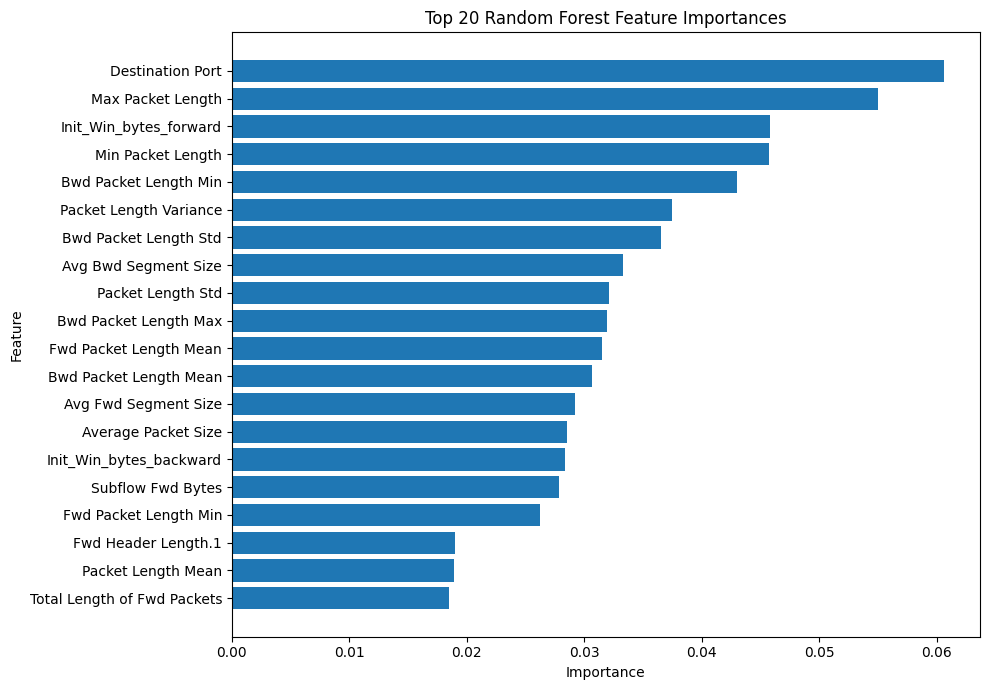

In [13]:
top_features = feature_importance.head(20).sort_values(
    by="Importance"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Feature Importances")

plt.tight_layout()
plt.show()

In [14]:
evaluation_results = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "ROC-AUC"
    ],
    "Score": [
        accuracy,
        precision,
        recall,
        f1,
        roc_auc
    ]
})

print("Evaluation Summary:")
print(evaluation_results)

Evaluation Summary:
      Metric     Score
0   Accuracy  0.997797
1  Precision  0.996826
2     Recall  0.995979
3   F1 Score  0.996402
4    ROC-AUC  0.999664


In [15]:
output_dir = "../data/CICIDS2017/ml_ready"

os.makedirs(output_dir, exist_ok=True)

evaluation_path = os.path.join(
    output_dir,
    "random_forest_evaluation.csv"
)

evaluation_results.to_csv(
    evaluation_path,
    index=False
)

print("Evaluation results saved successfully!")
print("Path:", evaluation_path)

Evaluation results saved successfully!
Path: ../data/CICIDS2017/ml_ready\random_forest_evaluation.csv


In [16]:
feature_importance_path = os.path.join(
    output_dir,
    "random_forest_feature_importance.csv"
)

feature_importance.to_csv(
    feature_importance_path,
    index=False
)

print("Feature importance saved successfully!")
print("Path:", feature_importance_path)

Feature importance saved successfully!
Path: ../data/CICIDS2017/ml_ready\random_forest_feature_importance.csv


In [17]:
print("=" * 60)
print("FINAL ML MODEL EVALUATION")
print("=" * 60)

print(f"Dataset size       : {len(df):,}")
print(f"Training samples   : {len(X_train):,}")
print(f"Testing samples    : {len(X_test):,}")
print(f"Number of features : {X.shape[1]}")
print()
print(f"Accuracy           : {accuracy:.4f}")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1 Score           : {f1:.4f}")
print(f"ROC-AUC            : {roc_auc:.4f}")

print("\nModel: Random Forest")
print("Purpose: Binary network attack detection")
print("=" * 60)

FINAL ML MODEL EVALUATION
Dataset size       : 288,277
Training samples   : 230,621
Testing samples    : 57,656
Number of features : 78

Accuracy           : 0.9978
Precision          : 0.9968
Recall             : 0.9960
F1 Score           : 0.9964
ROC-AUC            : 0.9997

Model: Random Forest
Purpose: Binary network attack detection
